## Predizioni statistiche sul successo dei film in termini di ticket venduti - modello di Regressione Logistica


Importazione delle librerie necessarie:

In [61]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

import requests
from bs4 import BeautifulSoup



Recupero del dataframe "pulito" da una cartella locale:

In [62]:
df_movies_clean = pd.read_csv("C:/Users/nicol/Downloads/df_imdb_movies_clean.csv")
df_movies_clean.head()

,movie_title,release_date,imdb_score,genre,overview,orig_title,orig_lang,budget,revenue,country,release_year,duration[min],color,director_name,review_num,movie_facebook_likes,director_facebook_likes,cast_total_facebook_likes,cast
0,the passion of the christ,02/25/2004,74.0,Drama,A graphic portrayal of the last twelve hours o...,The Passion of the Christ,English,25000000.0,6.223136e+08,AU,2004,120.0,Color,Mel Gibson,406.0,13000,0.0,705,"Christo Jivkov, Maia Morgenstern, Hristo Shopov"
1,avatar,12/17/2009,76.0,"Action, Adventure, Fantasy, Science Fiction","In the 22nd century, a paraplegic Marine is di...",Avatar,English,237000000.0,2.923706e+09,AU,2009,178.0,Color,James Cameron,723.0,33000,0.0,4834,"CCH Pounder, Joel David Moore, Wes Studi"
2,super mario bros.,06/10/1993,43.0,"Action, Adventure, Comedy, Family, Science Fic...","Mario and Luigi, plumbers from Brooklyn, find ...",Super Mario Bros.,English,42000000.0,2.084491e+07,AU,1993,104.0,Color,Annabel Jankel,36.0,0,5.0,7723,"Bob Hoskins, Fisher Stevens, Fiona Shaw"
3,creed,11/26/2015,74.0,Drama,The former World Heavyweight Champion Rocky Ba...,Creed,English,37000000.0,1.735676e+08,AU,2015,133.0,Color,Ryan Coogler,437.0,70000,0.0,15106,"Sylvester Stallone, Phylicia Rashad, Graham Mc..."
4,"the chronicles of narnia: the lion, the witch ...",12/26/2005,71.0,"Adventure, Family, Fantasy","Siblings Lucy, Edmund, Susan and Peter step th...","The Chronicles of Narnia: The Lion, the Witch ...",English,180000000.0,7.450131e+08,AU,2005,150.0,Color,Andrew Adamson,284.0,0,80.0,1317,"Jim Broadbent, Kiran Shah, Shane Rangi"


Controllo del datatype delle varie colonne:

In [63]:
df_movies_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1975 entries, 0 to 1974
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   movie_title                1975 non-null   str    
 1   release_date               1975 non-null   str    
 2   imdb_score                 1975 non-null   float64
 3   genre                      1975 non-null   str    
 4   overview                   1975 non-null   str    
 5   orig_title                 1975 non-null   str    
 6   orig_lang                  1975 non-null   str    
 7   budget                     1975 non-null   float64
 8   revenue                    1975 non-null   float64
 9   country                    1975 non-null   str    
 10  release_year               1975 non-null   int64  
 11  duration[min]              1975 non-null   float64
 12  color                      1972 non-null   str    
 13  director_name              1975 non-null   str    
 14  rev

Conversione della colonna 'release_date' in formato datetime:

In [64]:
df_movies_clean['release_date'] = df_movies_clean['release_date'].str.strip()
df_movies_clean['release_date'] = pd.to_datetime(df_movies_clean['release_date'], format='%m/%d/%Y')

In [65]:
df_movies_clean.rename(columns = {'budget': 'budget($)', 'revenue':'revenue($)'}, inplace = True)

___

### Definizione delle "features" utili a fare previsioni sul numero di ticket venduti.

Prezzo medio dei biglietti negli anni:

In [66]:
# Historical average ticket prices in US dollars (based on industry data)
def get_average_ticket_price(year):
    ticket_prices = {
        2023: 10.53,
        2022: 10.49,
        2021: 10.43,
        2020: 9.37,   # Pandemic year - lower prices
        2019: 9.16,
        2018: 9.11,
        2017: 8.97,
        2016: 8.65,
        2015: 8.43,
        2014: 8.17,
        2013: 8.13,
        2012: 7.96,
        2011: 7.93,
        2010: 7.89,
        2009: 7.50,
        2008: 7.18,
        2007: 6.88,
        2006: 6.55,
        2005: 6.41,
        2004: 6.21,
        2003: 6.03,
        2002: 5.81,
        2001: 5.66,
        2000: 5.39,
        1999: 5.06,
        1998: 4.69,
        1997: 4.59,
        1996: 4.42,
        1995: 4.35,
        1994: 4.18,
        1993: 4.14,
        1992: 4.15,
        1991: 4.21,
        1990: 4.23,
        1989: 3.97,
        1988: 3.91,
        1987: 3.65,
        1986: 3.54,
        1985: 3.55,
        1984: 3.36,
        1983: 3.15,
        1982: 2.94,
        1981: 2.78,
        1980: 2.69,
        1979: 2.52,
        1978: 2.34,
        1977: 2.23,
        1976: 2.13,
        1975: 2.05,
        1974: 1.89,
        1973: 1.77,
        1972: 1.69,
        1971: 1.65,
        1970: 1.55,
        1969: 1.42,
        1968: 1.34,
        1967: 1.22,
        1966: 1.17,
        1965: 1.12,
        1964: 1.08,
        1963: 1.02,
        1962: 0.98,
        1961: 0.94,
        1960: 0.90,
        1959: 0.86,
        1958: 0.83,
        1957: 0.80,
        1956: 0.77,
        1955: 0.74,
        1954: 0.71,
        1953: 0.68,
        1952: 0.65,
        1951: 0.63,
        1950: 0.61,
        1949: 0.58,
        1948: 0.56,
        1947: 0.54,
        1946: 0.52,
        1945: 0.50,
    }
    return ticket_prices.get(year, 5.00)  # Default to $5.00 if year not found

In [81]:
df_movies_clean['avg_ticket_price'] = df_movies_clean['release_year'].apply(get_average_ticket_price)


Lista di tutti i diversi generi presenti nel dataset:

In [68]:
unique_genres = df_movies_clean['genre'].str.split(',').explode().str.strip().unique()
unique_genres

<ArrowStringArray>
[          'Drama',          'Action',       'Adventure',         'Fantasy',
 'Science Fiction',          'Comedy',          'Family',       'Animation',
         'Mystery',         'Romance',        'Thriller',          'Horror',
           'Crime',             'War',        'TV Movie',         'History',
         'Western',           'Music',     'Documentary']
Length: 19, dtype: str

In [69]:
def avg_ticket_sales_by_genre(genre):
    return df_movies_clean[df_movies_clean['genre'].str.contains(genre)]['estimated_ticket_sales'].mean()
 
genre_ticket_sales = []
 
for el in unique_genres:
    genre_ticket_sales.append([el, avg_ticket_sales_by_genre(el)])
 
df_genre_ticket_sales = pd.DataFrame(genre_ticket_sales, columns=['genre', 'average_ticket_sales'])
df_genre_ticket_sales.reset_index(drop=True, inplace=True)
df_genre_ticket_sales.sort_values('average_ticket_sales', ascending=False, inplace=True)
df_genre_ticket_sales['average_ticket_sales'] = df_genre_ticket_sales['average_ticket_sales'].round(0).astype(int)
 
df_genre_ticket_sales

,genre,average_ticket_sales
7,Animation,45172678
2,Adventure,44834050
3,Fantasy,40087603
6,Family,36651115
4,Science Fiction,35614756
1,Action,33620116
13,War,25801163
9,Romance,24006868
5,Comedy,23838097
10,Thriller,23316743


Generi più popolari:

In [70]:
most_popular_genres_list = df_genre_ticket_sales['genre'].head(6)

df_movies_clean['pop_genre'] = [any(g in genre for g in most_popular_genres_list) if isinstance(genre, str) else False for genre in df_movies_clean['genre']]

df_movies_clean['pop_genre'].value_counts()

pop_genre
True     1146
False     829
Name: count, dtype: int64

Generi meno popolari:

In [71]:
niche_genres_list = df_genre_ticket_sales['genre'].tail(9)

df_movies_clean['niche_genre'] = [any(g in genre for g in niche_genres_list) if isinstance(genre, str) else False for genre in df_movies_clean['genre']]

df_movies_clean['niche_genre'].value_counts()

niche_genre
True     1193
False     782
Name: count, dtype: int64

Attori più influenti - Web scraping:

In [72]:
url = "https://www.watchmojo.com/articles/top-50-defining-actors-of-the-last-50-years"
page = requests.get(url)
soup = BeautifulSoup(page.content, "html.parser")
actor_links = soup.find_all("a", class_="item-title")

most_defining_actors = []

for actor in actor_links:
    actor_name = actor.get_text(strip=True)
    if actor_name:
        most_defining_actors.append(actor_name)

most_defining_actors


['Halle Berry',
 'Charlize Theron',
 'Dustin Hoffman',
 'Michelle Yeoh',
 'Margot Robbie',
 'Morgan Freeman',
 'Gary Oldman',
 'Amy Adams',
 'Jennifer Lawrence',
 'Matthew McConaughey',
 'Robert Downey Jr.',
 'Julianne Moore',
 'Paul Newman',
 "Lupita Nyong'o",
 'Helen Mirren',
 'Hugh Jackman',
 'Nicole Kidman',
 'Philip Seymour Hoffman',
 'Jodie Foster',
 'Ralph Fiennes',
 'Johnny Depp',
 'Angela Bassett',
 'Willem Dafoe',
 'Brad Pitt',
 'Sylvester Stallone',
 'Viola Davis',
 'Sigourney Weaver',
 'Keanu Reeves',
 'Glenn Close',
 'Christian Bale',
 'Arnold Schwarzenegger',
 'Frances McDormand',
 'Samuel L. Jackson',
 'Harrison Ford',
 'Anthony Hopkins',
 'Emma Stone',
 'Heath Ledger',
 'Joaquin Phoenix',
 'Julia Roberts',
 'Jack Nicholson',
 'Leonardo DiCaprio',
 'Robin Williams',
 'Robert De Niro',
 'Tom Cruise',
 'Cate Blanchett',
 'Daniel Day-Lewis',
 'Denzel Washington',
 'Al Pacino',
 'Tom Hanks',
 'Meryl Streep']

In [73]:
df_movies_clean['star_in_cast'] = [any(star in cast for star in most_defining_actors) if isinstance(cast, str) else False for cast in df_movies_clean['cast']]

df_movies_clean['star_in_cast'].value_counts()

star_in_cast
False    1632
True      343
Name: count, dtype: int64

Registi preferiti dal pubblico:

In [74]:
url_I = "https://nofilmschool.com/best-directors-of-all-time"
page = requests.get(url_I)
soup = BeautifulSoup(page.content, "html.parser")
director_links = soup.find_all("h3")

favourite_directors = []

for director in director_links:
    director_name = director.get_text(strip=True).split('. ', 1)[-1]
    if director_name:
        favourite_directors.append(director_name)

favourite_directors_top50 = favourite_directors[:49]
favourite_directors_top50

['Martin Scorsese',
 'Steven Spielberg',
 'Alfred Hitchcock',
 'Stanley Kubrick',
 'Quentin Tarantino',
 'Akira Kurosawa',
 'Christopher Nolan',
 'Francis Ford Coppola',
 'Spike Lee',
 'David Fincher',
 'Orson Welles',
 'Billy Wilder',
 'Ridley Scott',
 'Jane Campion',
 'John Ford',
 'James Cameron',
 'Ingmar Bergman',
 'Tim Burton',
 'Charlie Chaplin',
 'Federico Fellini',
 'David Lynch',
 'Peter Jackson',
 'Oscar Micheaux',
 'Roman Polanski',
 'Ang Lee',
 'John Singleton',
 'Agnes Varda',
 'Sergio Leone',
 'Jean-Luc Godard',
 'Alfonso Cuaron',
 'Sidney Lumet',
 'Clint Eastwood',
 'Jordan Peele',
 'Chantal Akerman',
 'Paul Thomas Anderson',
 'Andrei Tarkovsky',
 'John Huston',
 'David Lean',
 'Werner Herzog',
 'Nora Ephron',
 'Brian De Palma',
 'Frank Capra',
 'William Wyler',
 'Penny Marshall',
 'Joel Coen',
 'Alejandro González Iñárritu',
 'Miloš Forman',
 'Chloé Zhao',
 'Robert Altman']

In [75]:
star_director_list = ['Christopher Nolan', 'Quentin Tarantino', 'Martin Scorsese', 'Steven Spielberg', 'Ridley Scott', 'Tim Burton', 'David Fincher', 'James Cameron', 'Anthony Russo', 'Peter Jackson', 'Michael Bay', 'David Yates', 'Pierre Coffin', 'Chris Columbus', 'Gore Verbinski', 'Robert Zemeckis', 'Ron Howard', 'Clint Eastwood']

df_movies_clean['star_director'] = [1 if director in favourite_directors_top50 else 0 for director in df_movies_clean['director_name']]
df_movies_clean['star_director'].value_counts()

star_director
0    1844
1     131
Name: count, dtype: int64

Periodo di uscita di un film:

In [76]:
def christmas_period(date):

    if (date.month == 12 and date.day >= 20) or (date.month == 1 and date.day <= 6):
        
        return 1
    
    else:
         
        return 0


df_movies_clean['christmas_period'] = df_movies_clean['release_date'].apply(christmas_period)
df_movies_clean['christmas_period'].value_counts()

christmas_period
0    1873
1     102
Name: count, dtype: int64

In [77]:
def summer_period(date):

    
        if (date.month in {6, 7, 8}):
            return 1
        else:
            return 0


df_movies_clean['summer_period'] = df_movies_clean['release_date'].apply(summer_period)
df_movies_clean['summer_period'].value_counts()

summer_period
0    1435
1     540
Name: count, dtype: int64

Film a colori o in bianco e nero:

In [78]:
df_movies_clean['is_color'] = [1 if el == 'Color' else 0 for el in df_movies_clean['color']]
df_movies_clean['is_color'].value_counts()

is_color
1    1918
0      57
Name: count, dtype: int64

### Definizione della variabile "target":

Stima dei biglietti venduti:

In [80]:
df_movies_clean['estimated_ticket_sales'] = df_movies_clean['revenue($)'] / df_movies_clean['avg_ticket_price']

df_movies_clean['estimated_ticket_sales'].describe()

count    1.975000e+03
mean     2.616520e+07
std      3.463910e+07
min      0.000000e+00
25%      5.931461e+06
50%      1.372988e+07
75%      3.196125e+07
max      4.843106e+08
Name: estimated_ticket_sales, dtype: float64

In [82]:
df_movies_clean['Sales SUCCESS'] = [1 if el >= 25000000 else 0 for el in df_movies_clean['estimated_ticket_sales']] #soglia: 25 milioni di ticket venduti
df_movies_clean['Sales SUCCESS'].value_counts()

Sales SUCCESS
0    1342
1     633
Name: count, dtype: int64

In [83]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

columns_to_normalize = df_movies_clean[['budget($)', 'release_year', 'duration[min]']]

scaler = MinMaxScaler()

df_movies_clean[['budget($)', 'release_year', 'duration[min]']] = scaler.fit_transform(df_movies_clean[['budget($)', 'release_year', 'duration[min]']])

df_movies_clean_normalized = df_movies_clean[['Sales SUCCESS', 'budget($)', 'release_year', 'duration[min]', 'pop_genre', 'niche_genre', 'star_director', 'star_in_cast', 'christmas_period', 'summer_period', 'is_color']]


Matrice di correlazione fra i vari predittori ed il target:

In [84]:
df_movies_clean_normalized[['Sales SUCCESS','budget($)', 'duration[min]','release_year','christmas_period','summer_period','star_director','star_in_cast','pop_genre','niche_genre','is_color']].corr()

,Sales SUCCESS,budget($),duration[min],release_year,christmas_period,summer_period,star_director,star_in_cast,pop_genre,niche_genre,is_color
Sales SUCCESS,1.000000,0.541986,0.246689,-0.075575,0.060342,0.109363,0.091617,0.192082,0.225782,-0.249283,0.008223
budget($),0.541986,1.000000,0.301836,0.255593,0.065508,0.080087,0.060996,0.214412,0.390703,-0.321264,0.062081
duration[min],0.246689,0.301836,1.000000,-0.155349,0.055642,-0.005446,0.300392,0.209213,-0.013024,0.145343,-0.056786
release_year,-0.075575,0.255593,-0.155349,1.000000,-0.019605,-0.020643,-0.224228,0.012585,0.028195,-0.054016,0.172706
christmas_period,0.060342,0.065508,0.055642,-0.019605,1.000000,-0.143154,0.048123,0.056079,0.026954,-0.068363,-0.014434
summer_period,0.109363,0.080087,-0.005446,-0.020643,-0.143154,1.000000,-0.035687,0.000653,0.075186,-0.065475,0.010754
star_director,0.091617,0.060996,0.300392,-0.224228,0.048123,-0.035687,1.000000,0.135609,-0.041281,0.082663,-0.160656
star_in_cast,0.192082,0.214412,0.209213,0.012585,0.056079,0.000653,0.135609,1.000000,0.002636,0.007681,0.039114
pop_genre,0.225782,0.390703,-0.013024,0.028195,0.026954,0.075186,-0.041281,0.002636,1.000000,-0.323576,0.061739
niche_genre,-0.249283,-0.321264,0.145343,-0.054016,-0.068363,-0.065475,0.082663,0.007681,-0.323576,1.000000,-0.083914


### Assegnazione della variabile target e delle variabili predittrici e divisione del dataset in TRAINING set e TEST set.

In [85]:
y = df_movies_clean_normalized['Sales SUCCESS']
X = df_movies_clean_normalized[['budget($)','release_year','duration[min]','christmas_period','star_director','summer_period', 'star_in_cast', 'pop_genre', 'niche_genre']] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Allenamento del modello sul TRANING set:

In [86]:
log_reg = LogisticRegression(max_iter=1000, class_weight = 'balanced')
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Calcolo dell'intercetta e dei coefficienti della regressione logistica:

In [87]:
print('Intercept:', log_reg.intercept_)
print('Coefficients:', log_reg.coef_[0])

Intercept: [0.4437572]
Coefficients: [ 8.15577699 -2.67773923  2.14348081  0.38273055  0.05720234  0.48955669
  0.60152261  0.18357901 -0.70760928]


Definizione delle predizioni sulla base del TEST set:

In [88]:
y_pred = log_reg.predict(X_test)

Matrice di confusione:

In [89]:
cm = metrics.confusion_matrix(y_test, y_pred)
cm

array([[340,  66],
       [ 53, 134]])

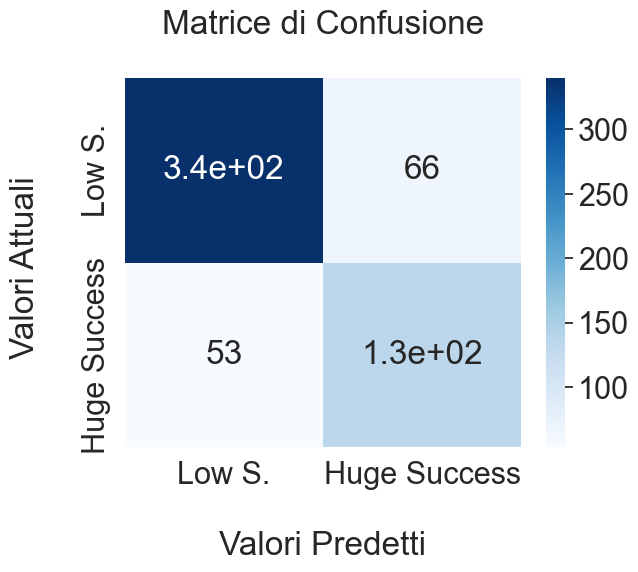

In [90]:
sns.set(font_scale=2)

ax = sns.heatmap(cm, annot=True, cmap='Blues')

ax.set_title('Matrice di Confusione\n');
ax.set_xlabel('\nValori Predetti')
ax.set_ylabel('Valori Attuali \n');

ax.yaxis.set_ticklabels(['Low S.','Huge Success'])
ax.xaxis.set_ticklabels(['Low S.','Huge Success'])

plt.show()

Parametri indicativi della bontà del modello:

In [91]:
print('Accuratezza:' , (round(metrics.accuracy_score(y_test, y_pred), 2))*100, '%')

Accuratezza: 80.0 %


In [92]:
print ('Precisione:' , (round(metrics.precision_score(y_test, y_pred), 3))*100,'%')

Precisione: 67.0 %


In [93]:
print ('Richiamo:' , (round(metrics.recall_score(y_test, y_pred), 3))*100,'%')

Richiamo: 71.7 %


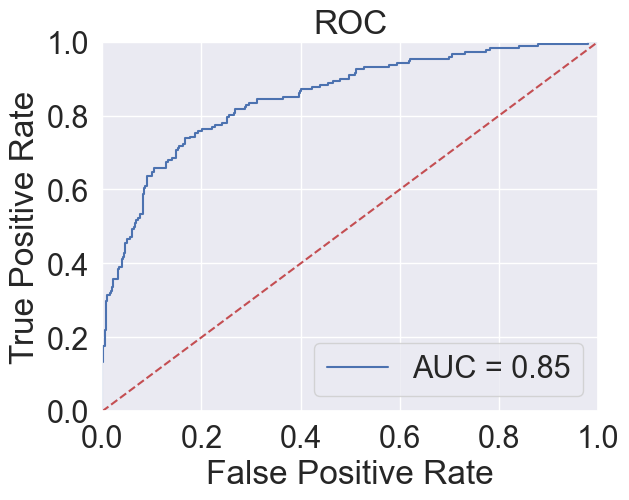

In [95]:

probs = log_reg.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)


plt.title('ROC')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

## Conclusioni:

I risultati relativi ai parametri di accuratezza e ROC-AUC rappresentano, considerato il contesto di analisi, un discreto punto di partenza per un modello che si propone di fare previsioni sul successo, in termini di biglietti venduti, di un determinato film. I valori di precisione e richiamo risultano invece leggermente più bassi e ciò riflette la minor efficacia del modello nel predire correttamente tutti i casi positivi (nel nostro caso i film che superano i 25 milioni di biglietti venduti). Le imperfezioni del modello, comunque, non sono così elevate da rendere il modello inutile o inattendibile, ma vanno invece ricondotte all'esistenza di fattori esterni al modello, come l'efficacia della promozione del film, la competizione fra film usciti nello stesso periodo, l'originalità della trama e, più in generale, i temi trattati dal film stesso, senza dimenticare l'effetto dovuto al passa-parola fra le persone durante i mesi di uscita del film.